In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /content/Data/cats_and_dogs_filtered.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model

In [3]:
# Unzipping the file
local_zip = '/content/Data/cats_and_dogs_filtered.zip'
zipref = zipfile.ZipFile(local_zip)
zipref.extractall('/content/Data')

In [4]:
os.listdir('/content/Data/cats_and_dogs_filtered')

['vectorize.py', 'train', 'validation']

In [5]:
print(os.listdir('/content/Data/cats_and_dogs_filtered/train'))
print(os.listdir('/content/Data/cats_and_dogs_filtered/validation'))

['dogs', 'cats']
['dogs', 'cats']


In [6]:
base_dir  = '/content/Data/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir   = os.path.join(val_dir, 'cats')
val_dogs_dir   = os.path.join(val_dir, 'dogs')

print(train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir, sep = '\n')

/content/Data/cats_and_dogs_filtered/train/cats
/content/Data/cats_and_dogs_filtered/train/dogs
/content/Data/cats_and_dogs_filtered/validation/cats
/content/Data/cats_and_dogs_filtered/validation/dogs


In [7]:
print('Number of training cat images   : ', len(os.listdir(train_cats_dir)))
print('Number of training dog images   : ', len(os.listdir(train_dogs_dir)))
print('Number of validation cat images : ', len(os.listdir(val_cats_dir)))
print('Number of validation dog images : ', len(os.listdir(val_dogs_dir)))

Number of training cat images   :  1000
Number of training dog images   :  1000
Number of validation cat images :  500
Number of validation dog images :  500


In [8]:
print(os.listdir(train_cats_dir)[:10])
print(os.listdir(train_dogs_dir)[:10])

['cat.565.jpg', 'cat.97.jpg', 'cat.783.jpg', 'cat.454.jpg', 'cat.315.jpg', 'cat.803.jpg', 'cat.201.jpg', 'cat.514.jpg', 'cat.978.jpg', 'cat.734.jpg']
['dog.122.jpg', 'dog.816.jpg', 'dog.195.jpg', 'dog.761.jpg', 'dog.763.jpg', 'dog.490.jpg', 'dog.108.jpg', 'dog.416.jpg', 'dog.638.jpg', 'dog.299.jpg']


(374, 500, 3)


(-0.5, 499.5, 373.5, -0.5)

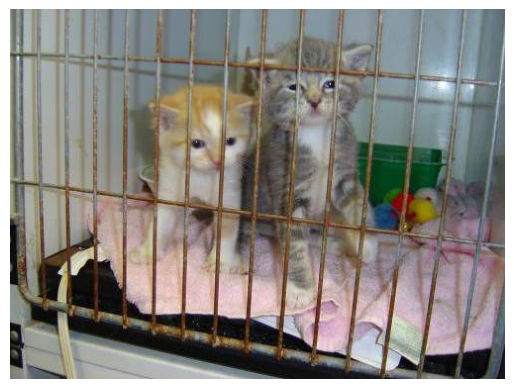

In [9]:
# Accessing and visualizing  a cat image
cat_image_path = os.path.join(train_cats_dir, 'cat.454.jpg')
cat_image = mpimg.imread(cat_image_path)
print(cat_image.shape)

plt.imshow(cat_image)
plt.axis('off')

(262, 350, 3)


(-0.5, 349.5, 261.5, -0.5)

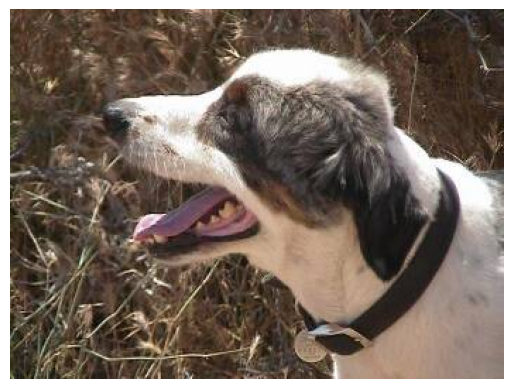

In [10]:
# Accessing and visualizing  a dog image
dog_image_path = os.path.join(train_dogs_dir, 'dog.122.jpg')
dog_image = mpimg.imread(dog_image_path)
print(dog_image.shape)

plt.imshow(dog_image)
plt.axis('off')

In [11]:
train_cat_images = os.listdir(train_cats_dir)[:30]
train_dog_images = os.listdir(train_dogs_dir)[:30]

cat_image_paths = [os.path.join(train_cats_dir, image) for image in train_cat_images]
dog_image_paths = [os.path.join(train_dogs_dir, image) for image in train_dog_images]

image_paths = cat_image_paths + dog_image_paths
image_paths

['/content/Data/cats_and_dogs_filtered/train/cats/cat.565.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.97.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.783.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.454.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.315.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.803.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.201.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.514.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.978.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.734.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.754.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.257.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.639.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.831.jpg',
 '/content/Data/cats_and_dogs_filtered/train/cats/cat.444.jpg',
 '/content/Data/cats_and_dogs_filtered/tr

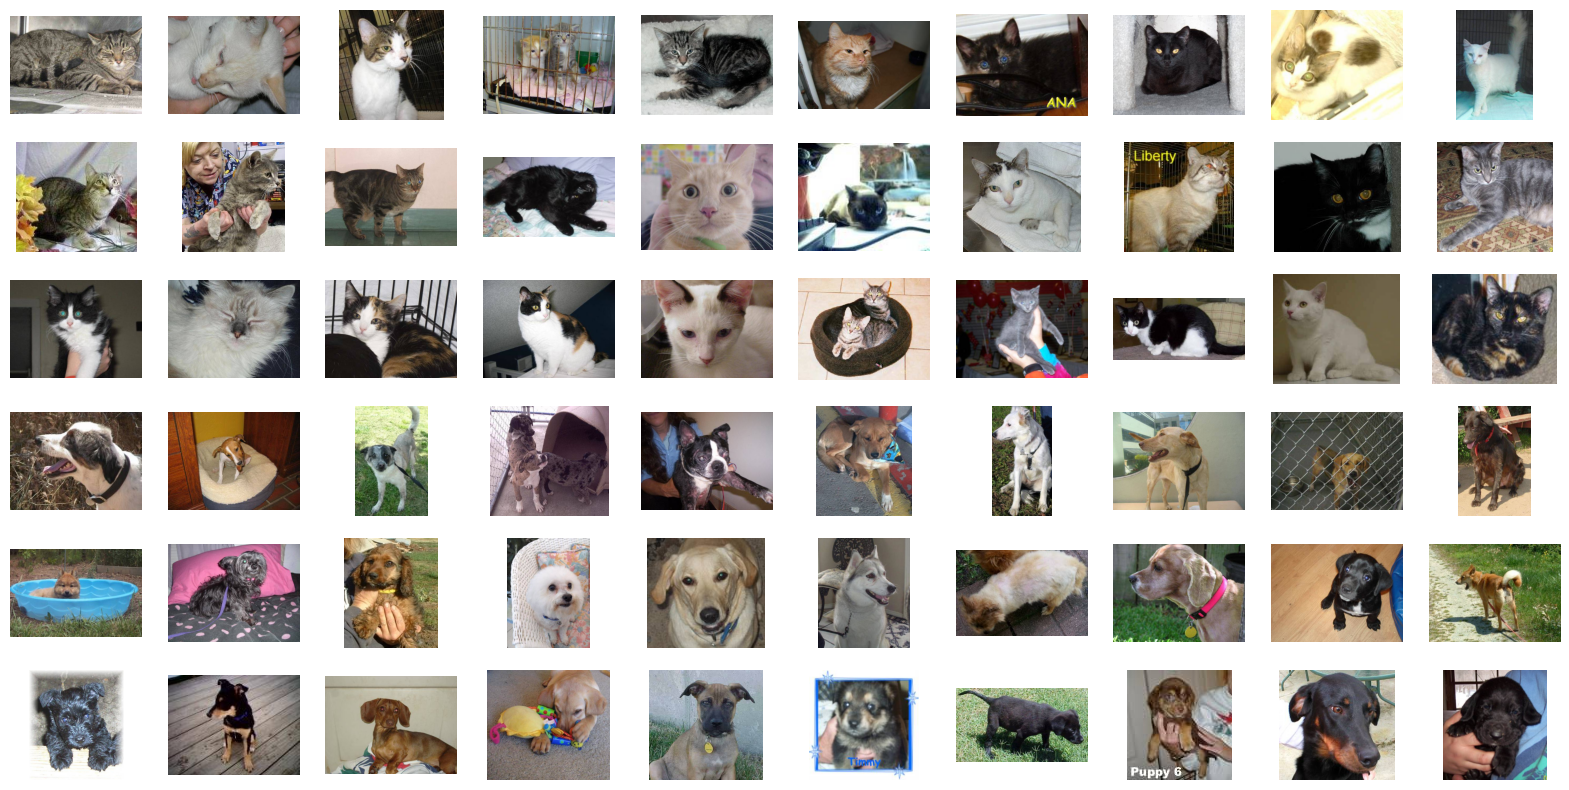

In [12]:
plt.figure(figsize = (20,10))
for i in range(60):
  plt.subplot(6,10, i+1)
  image = mpimg.imread(image_paths[i])
  plt.imshow(image)
  plt.axis('off')

In [13]:
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 0.1,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    vertical_flip = True,
    horizontal_flip = True
)

# flow_from_directory is used when data is on secondary storage
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 20,
    class_mode = 'binary'
)

Found 2000 images belonging to 2 classes.


In [14]:
val_datagen = ImageDataGenerator(rescale = 1/255)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (150,150),
    batch_size = 20,
    class_mode = 'binary'
)

Found 1000 images belonging to 2 classes.


# --------------------------------------------------------------------------------------------------------------------
# Using InceptionV3

In [15]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5 \
    -O /content/Data/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5

--2023-08-27 07:29:30--  https://storage.googleapis.com/mledu-datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.145.128, 74.125.128.128, 74.125.143.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.145.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 87910968 (84M) [application/x-hdf]
Saving to: ‘/content/Data/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5’

/content/Data/incep 100%[===================>]  83.84M  26.2MB/s    in 3.2s    

2023-08-27 07:29:34 (26.2 MB/s) - ‘/content/Data/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5’ saved [87910968/87910968]



In [16]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

pre_trained_model = InceptionV3(input_shape = (150,150,3),
                                include_top = False,
                                weights = None)

local_weights_file = '/content/Data/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

pre_trained_model.load_weights(local_weights_file)

for layer in pre_trained_model.layers:
  layer.trainable = False

#pre_trained_model.summary()

In [17]:
'''
last_layer = pre_trained_model.get_layer('mixed7')
print('Last Layer Output Shape : ', last_layer.output_shape)
last_output = last_layer.output

x = Flatten()(last_output)
x = Dense(1024, activation = 'relu')(x)
x = Dense(1, activation = 'sigmoid')(x)

final_model = Model(pre_trained_model, x)
final_model.summary()
'''

"\nlast_layer = pre_trained_model.get_layer('mixed7')\nprint('Last Layer Output Shape : ', last_layer.output_shape)\nlast_output = last_layer.output\n\nx = Flatten()(last_output)\nx = Dense(1024, activation = 'relu')(x)\nx = Dense(1, activation = 'sigmoid')(x)\n\nfinal_model = Model(pre_trained_model, x)\nfinal_model.summary()\n"

In [18]:
model = keras.models.Sequential()
model.add(pre_trained_model)
model.add(Flatten())
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 3, 3, 2048)        21802784  
                                                                 
 flatten (Flatten)           (None, 18432)             0         
                                                                 
 dense (Dense)               (None, 1024)              18875392  
                                                                 
 dense_1 (Dense)             (None, 1)                 1025      
                                                                 
Total params: 40,679,201
Trainable params: 18,876,417
Non-trainable params: 21,802,784
_________________________________________________________________


In [19]:
model.compile(loss = 'binary_crossentropy',
              optimizer = Adam(),
              metrics = ['accuracy'])

In [20]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 40,
    verbose = 1
)

Epoch 1/40
100/100 [==============================] - 26s 177ms/step - loss: 4.5668 - accuracy: 0.8105 - val_loss: 1.4589 - val_accuracy: 0.8940
Epoch 2/40
100/100 [==============================] - 16s 163ms/step - loss: 1.4476 - accuracy: 0.8700 - val_loss: 0.2222 - val_accuracy: 0.9520
Epoch 3/40
100/100 [==============================] - 18s 176ms/step - loss: 0.4304 - accuracy: 0.8865 - val_loss: 0.1262 - val_accuracy: 0.9600
Epoch 4/40
100/100 [==============================] - 17s 167ms/step - loss: 0.2796 - accuracy: 0.8965 - val_loss: 0.1391 - val_accuracy: 0.9560
Epoch 5/40
100/100 [==============================] - 18s 185ms/step - loss: 0.2150 - accuracy: 0.9170 - val_loss: 0.1342 - val_accuracy: 0.9490
Epoch 6/40
100/100 [==============================] - 16s 164ms/step - loss: 0.2148 - accuracy: 0.9000 - val_loss: 0.0991 - val_accuracy: 0.9590
Epoch 7/40
100/100 [==============================] - 16s 165ms/step - loss: 0.2122 - accuracy: 0.9145 - val_loss: 0.1046 - val_ac

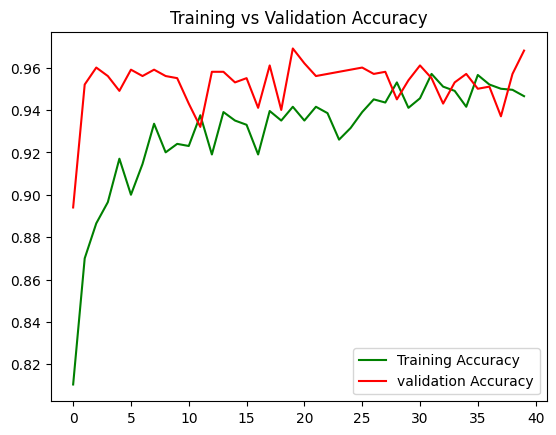

In [21]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure()
plt.plot(train_acc , color = 'green', label = 'Training Accuracy')
plt.plot(val_acc , color = 'reabout:blank#blockedd', label = 'validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


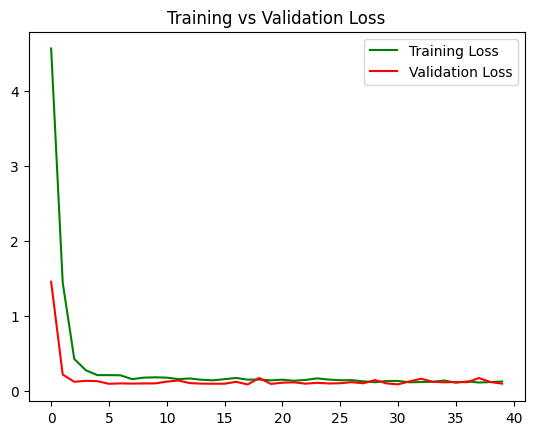

In [22]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(train_loss , color = 'green', label = 'Training Loss')
plt.plot(val_loss , color = 'red', label = 'Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()